In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data, skipping the first 3 messy header rows
# We will manually assign the correct column names
df = pd.read_csv('GC_F_historical.csv', skiprows=3, 
                 names=['Date', 'Close', 'High', 'Low', 'Open', 'Volume'])

# 2. Drop any completely empty rows (like the last row in your CSV)
df.dropna(inplace=True)

# 3. Convert the 'Date' column to actual datetime objects (Format: Day/Month/Year)
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# 4. Ensure all price/volume columns are numeric
cols_to_numeric =['Close', 'High', 'Low', 'Open', 'Volume']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col])

# 5. Sort by Date from oldest to newest (Crucial for AI Time-Series prediction)
df = df.sort_values('Date').reset_index(drop=True)

print("✅ Data successfully cleaned! Here are the first 5 rows:")
display(df.head())

✅ Data successfully cleaned! Here are the first 5 rows:


,Date,Close,High,Low,Open,Volume
0,2016-03-17,1264.500000,1270.099976,1255.900024,1261.500000,27.0
1,2016-03-18,1253.800049,1264.400024,1251.500000,1257.099976,542.0
2,2016-03-21,1243.800049,1256.199951,1243.400024,1256.199951,1061.0
3,2016-03-22,1248.199951,1252.400024,1243.800049,1244.000000,20.0
4,2016-03-23,1223.699951,1247.699951,1218.599976,1247.699951,28.0


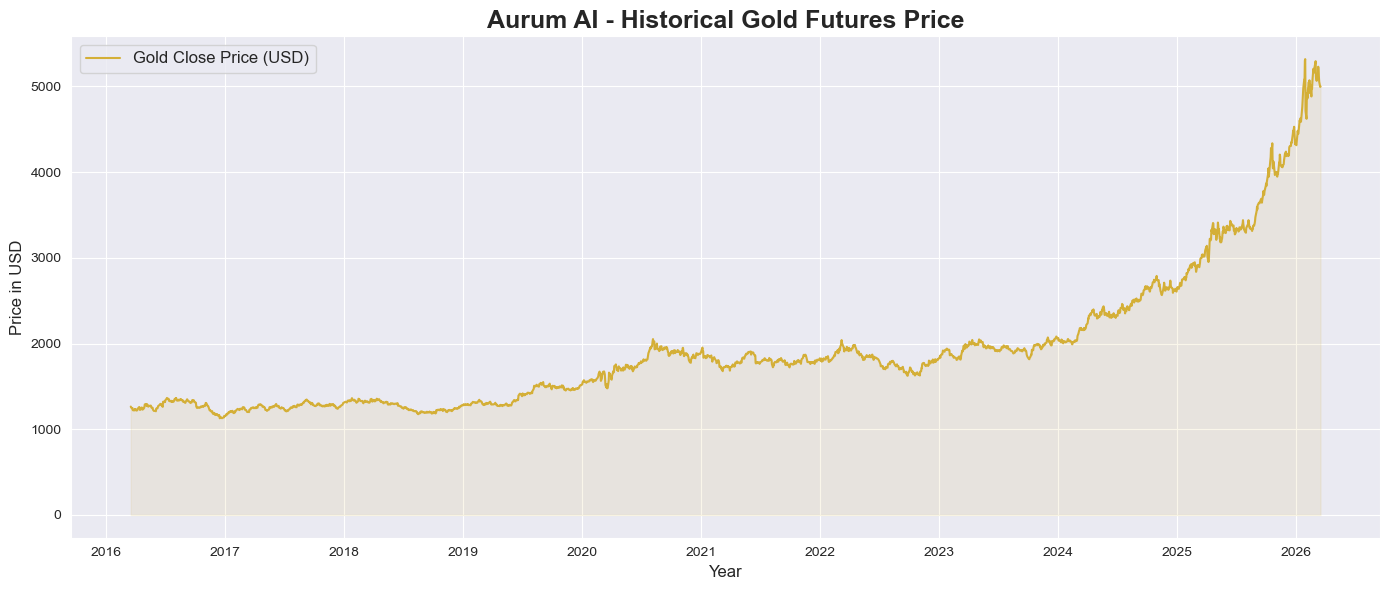

In [175]:
# Set the style
sns.set_style("darkgrid")

# Create the plot
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], color='#D4AF37', linewidth=1.5, label='Gold Close Price (USD)')

# Add titles and labels
plt.title('Aurum AI - Historical Gold Futures Price', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price in USD', fontsize=12)

# Fill the area under the curve for a premium look
plt.fill_between(df['Date'], df['Close'], color='#D4AF37', alpha=0.1)

plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

Add Technical Indicators (Feature Engineering)

In [176]:
import numpy as np

# 1. Add 20-day and 50-day Simple Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# 2. The first 50 days won't have a 50-day average, so they become "NaN" (Not a Number)
# We must drop these empty rows so the AI doesn't crash
df_ml = df.dropna().reset_index(drop=True)

print("Added Moving Averages. Here is the new data:")
display(df_ml[['Date', 'Close', 'SMA_20', 'SMA_50']].head())

Added Moving Averages. Here is the new data:


,Date,Close,SMA_20,SMA_50
0,2016-05-26,1220.099976,1265.599994,1249.761992
1,2016-05-27,1213.800049,1261.829999,1248.747993
2,2016-05-31,1214.800049,1257.835004,1247.967993
3,2016-06-01,1211.900024,1253.895007,1247.329993
4,2016-06-02,1209.800049,1250.720007,1246.561995


Scale the Data and Create Sequences

In [177]:
from sklearn.preprocessing import MinMaxScaler

# 1. Isolate the 'Close' price (this is what we want to predict)
dataset = df_ml.filter(['Close']).values

# 2. Scale the data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# 3. Define how many past days the AI should look at to predict the next day
sequence_length = 60  # Look at the past 60 days

X =[] # Inputs (Past 60 days)
y =[] # Targets (Day 61)

# Loop through the data to create these 60-day bundles
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

# 4. Convert lists to numpy arrays
X, y = np.array(X), np.array(y)

# 5. Neural Networks (LSTM) expect a 3D shape: (Samples, Time Steps, Features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"Shape of X (Inputs): {X.shape}")
print(f"Shape of y (Targets): {y.shape}")
print("Data is scaled, bundled, and 100% ready for the AI!")

Shape of X (Inputs): (2404, 60, 1)
Shape of y (Targets): (2404,)
Data is scaled, bundled, and 100% ready for the AI!


Feature Engineering = Giving the AI cheat sheets (trend lines).
Scaling = Shrinking large dollar amounts into decimals so the math is fast.
Sequencing = Chopping the data into 60-day "flashcards" for the AI to study.
LSTM = Long-short term memory.The AI brain that is really good at studying those flashcards because it has a memory. 

Build AI brain

In [178]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# 1. Initialize the AI (Think of this as waking up a new, blank brain)
model = Sequential()

# 2. Add the first LSTM layer (The Student's "Short-Term Memory")
# 'units=50' means we are giving it 50 "neurons" to think with
# 'return_sequences=True' means it will pass its thoughts to the next layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
# Dropout helps the AI not overthink (prevents it from just memorizing the answers)
model.add(Dropout(0.2))

# 3. Add a second LSTM layer (The Student's "Long-Term Memory")
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# 4. Add the Output Layer (This is where the AI shouts out its final guessed price)
model.add(Dense(units=1))

# 5. Compile the AI
# 'adam' is the optimizer (the teacher that tells it how to improve)
# 'mean_squared_error' is the SCORE (how it calculates how wrong its guess was)
model.compile(optimizer='adam', loss='mean_squared_error')

print("AI Brain (LSTM) successfully built and ready to study!")
model.summary()

AI Brain (LSTM) successfully built and ready to study!


c:\Users\hpvic\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_38 (LSTM)                  │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_39 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Train the AI

The AI is starting its study session...
Epoch 1/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0066
Epoch 2/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.9781e-04
Epoch 3/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.9047e-04
Epoch 4/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.7623e-04
Epoch 5/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.9307e-04
Epoch 6/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.8433e-04
Epoch 7/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.9525e-04
Epoch 8/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.3984e-04
Epoch 9/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.3292e-04
Epoch 10/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.4656e-04
Epoch 11/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.4313e-04
Epoch 12/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.2380e-04
Epoch 13/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 6.1617e-04
Epoch 14/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/ste

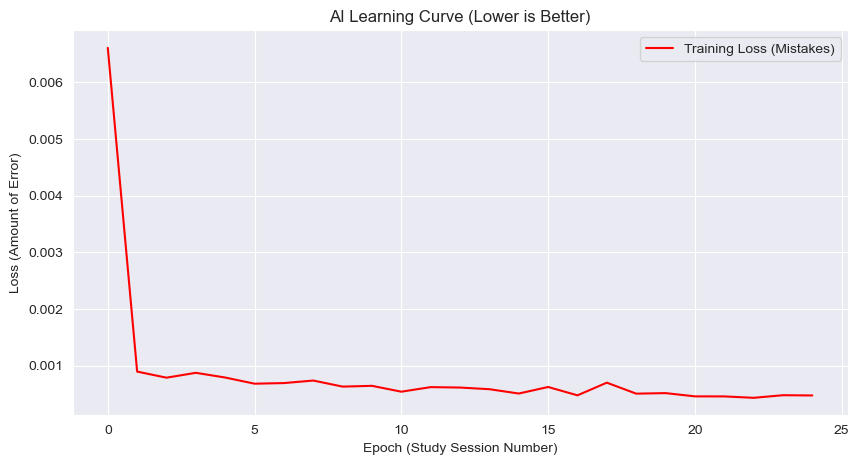

In [179]:
import matplotlib.pyplot as plt

print("The AI is starting its study session...")

# 1. Train the AI! 
# We are passing it the Questions (X) and the Answers (y)
history = model.fit(X, y, epochs=25, batch_size=30)

print("Training Complete! The AI is now an expert on historical Gold patterns.")

# 2. Let's visualize how the AI learned over time
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], color='red', label='Training Loss (Mistakes)')
plt.title('AI Learning Curve (Lower is Better)')
plt.xlabel('Epoch (Study Session Number)')
plt.ylabel('Loss (Amount of Error)')
plt.legend()
plt.show()

Ultimate Test : check Orange line perfectly hugs and follows the Blue line up and down through the years

🤖 AI is now predicting the prices...
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


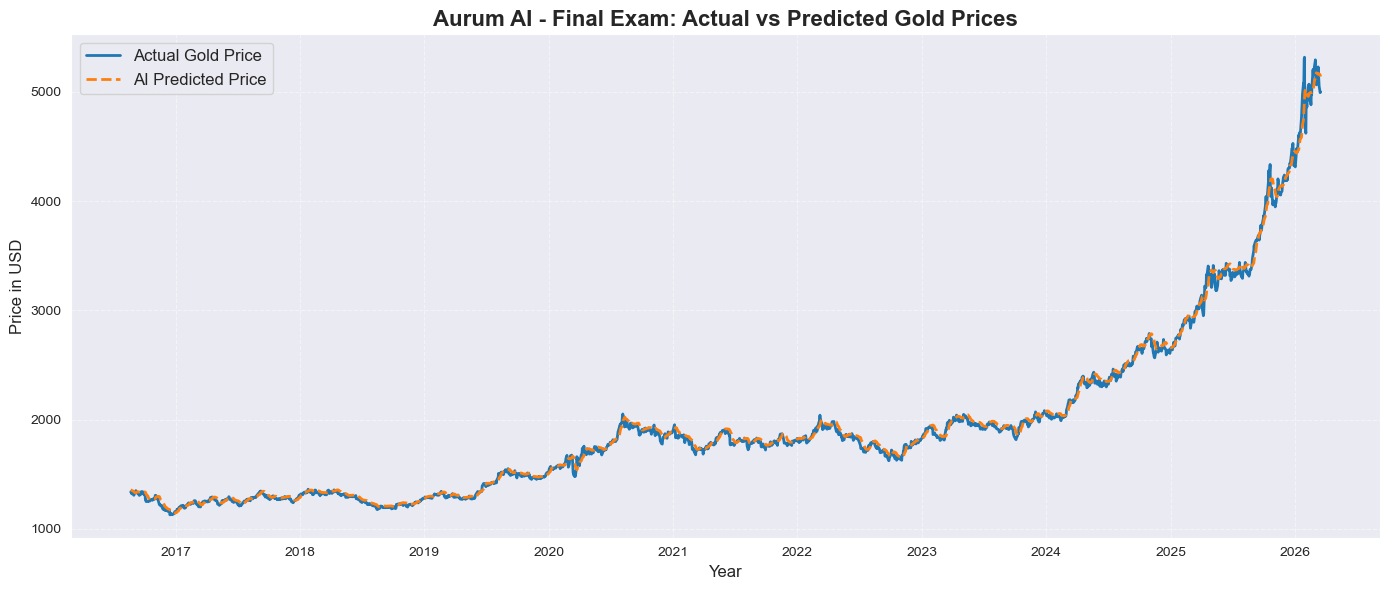

In [180]:
# 1. Ask the AI to predict the prices based on the flashcards (X)
print("🤖 AI is now predicting the prices...")
predicted_scaled = model.predict(X)

# 2. The AI gives answers in decimals (0 to 1). 
# We need to un-scale them back to real Dollars!
predicted_prices = scaler.inverse_transform(predicted_scaled)
real_prices = scaler.inverse_transform(y.reshape(-1, 1))

# 3. Create a beautiful chart comparing the REAL vs PREDICTED prices
plt.figure(figsize=(14, 6))

# Plot actual prices in Blue
# Note: We skip the first 60 days because the AI needed them to start guessing day 61
plt.plot(df_ml['Date'][60:], real_prices, color='#1f77b4', label='Actual Gold Price', linewidth=2)

# Plot AI predictions in Orange
plt.plot(df_ml['Date'][60:], predicted_prices, color='#ff7f0e', label='AI Predicted Price', linestyle='--', linewidth=2)

plt.title('Aurum AI - Final Exam: Actual vs Predicted Gold Prices', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price in USD', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [181]:
#import os

# '..' tells Python to go up one level to the main project folder
target_folder = os.path.join('..', 'Models')

# 1. Create the folder if it doesn't exist
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
    print(f"Created folder: {target_folder}")

# 2. Save the model there
model_path = os.path.join(target_folder, 'gold_price_model.keras')
model.save(model_path)

#print(f"AI Brain successfully saved at: {model_path}")

 Scaler (the tool that shrinks numbers to 0-1) to understand new data.

In [ ]:
import os
import joblib

# 1. Path to the Models folder (outside Data_preparation)
scaler_folder = os.path.join('..', 'Models')

# 2. Create the folder if it doesn't exist
if not os.path.exists(scaler_folder):
    os.makedirs(scaler_folder)

# 3. Save the scaler
# Assuming your scaler variable is named 'scaler' from our previous steps
joblib.dump(scaler, os.path.join(scaler_folder, 'gold_scaler.bin'))

print("Scaler saved successfully in the Models folder!")

NameError: name 'scaler' is not defined